# Cats vs Dogs: классификатор и объяснение его решений (Grad-CAM)

Продолжение предыдущего дз (`CatsDogs_CNN_TransferLearning.ipynb`): тот же датасет, тот же baseline CNN и тот же ResNet18. Добавлено:
1. проверка дубликатов до разбиения;
2. scheduler, early stopping и сохранение лучшего checkpoint;
3. метрики Precision, Recall, F1, Confusion Matrix, разбор ошибок с вероятностями классов;
4. Grad-CAM для правильных и ошибочных ответов, поиск примеров, где сеть смотрит на фон;
5. функция `classify_image` для одного нового изображения.

In [1]:
!pip install -q grad-cam imagehash

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import copy
import time
import random
from pathlib import Path

import imagehash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, ConfusionMatrixDisplay)

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 4

DATA_ROOT = Path("/kaggle/input/datasets/karakaggle/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages")
OUTPUT_DIR = Path("/kaggle/working/cats_dogs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"  # смешанная точность ускоряет обучение на GPU
print("Device:", DEVICE)
print("Содержимое DATA_ROOT:", sorted(p.name for p in DATA_ROOT.iterdir()))


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

Device: cuda
Содержимое DATA_ROOT: ['Cat', 'Dog']


## 1. Данные: проверка изображений и баланс классов

В этом датасете есть битые файлы: нулевого размера, не картинки, обрезанные. `ImageFolder` принимает функцию `is_valid_file`, поэтому каждый файл один раз открываем через PIL и оставляем только те, что открылись.

**Почему картинки кэшируются.** Декодировать JPEG и крутить полноразмерную картинку на каждой эпохе слишком дорого: процессор загружен на 100%, а GPU ждёт данные. Поэтому все картинки один раз декодируем, сжимаем до 144x144 и держим в памяти как `uint8`-тензоры (около 1,5 ГБ). Аугментации потом считаются на маленьких тензорах и стоят почти ничего.

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Кэш картинок: (24959, 3, 144, 144) torch.uint8
Файлов на диске: 24961, годных картинок: 24959, отброшено: 2
Классы: ['Cat', 'Dog']
Баланс: {'Cat': np.int64(12490), 'Dog': np.int64(12469)}


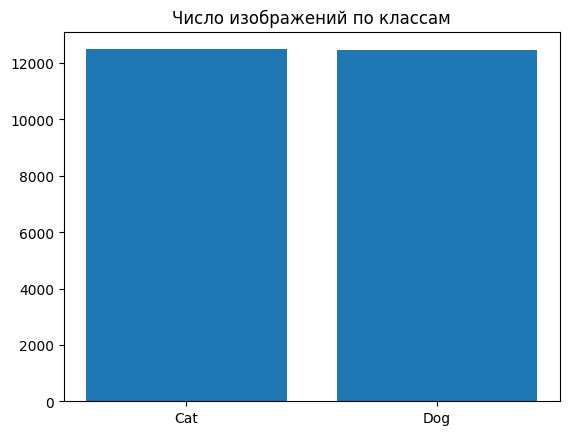

In [20]:
ImageFile.LOAD_TRUNCATED_IMAGES = True  # обрезанные JPEG читаем, а не падаем


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)  # статистика ImageNet,
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)   # нужна ResNet; своей CNN не мешает

CACHE_SIZE = 144  # чуть больше IMG_SIZE, чтобы кропу было из чего вырезать

# Аугментации идут по uint8-тензорам CACHE_SIZE x CACHE_SIZE, не по полноразмерным JPEG.
train_tf = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), antialias=True),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToDtype(torch.float32, scale=True),  # uint8 0..255 -> float 0..1
    v2.Normalize(MEAN.flatten(), STD.flatten()),
])
to_cache = v2.Compose([v2.Resize((CACHE_SIZE, CACHE_SIZE), antialias=True), v2.PILToTensor()])
eval_tf = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(MEAN.flatten(), STD.flatten()),
])
eval_tf = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(MEAN.flatten(), STD.flatten()),
])

# Единственный проход по JPEG на весь ноутбук: декодируем, сжимаем, складываем в один тензор.
raw = ImageFolder(
    DATA_ROOT,
    is_valid_file=is_valid_image,
    transform=v2.Compose([v2.Resize((CACHE_SIZE, CACHE_SIZE), antialias=True), v2.PILToTensor()]),
)
images = torch.cat([X for X, _ in DataLoader(raw, batch_size=256, num_workers=NUM_WORKERS)])
print("Кэш картинок:", tuple(images.shape), images.dtype)

n_files = sum(1 for p in DATA_ROOT.rglob("*") if p.is_file())
print(f"Файлов на диске: {n_files}, годных картинок: {len(raw)}, отброшено: {n_files - len(raw)}")

targets = np.array(raw.targets)
classes = raw.classes
print("Классы:", classes)
print("Баланс:", dict(zip(classes, np.bincount(targets))))

plt.bar(classes, np.bincount(targets))
plt.title("Число изображений по классам")
plt.show()

### Дубликаты

Для каждой картинки считается перцептивный хэш `phash` (64 бита, устойчив к пережатию и небольшому масштабированию). Картинки с одинаковым хэшем считаются копиями: остаётся одна. Если у копий разные метки (одно фото лежит и в `Cat`, и в `Dog`), удаляются все, потому что верную метку не определить. Дубликаты убираются **до** разбиения, иначе копия одной картинки попадёт и в train, и в test, и test завысит качество.

In [4]:
paths = np.array([p for p, _ in raw.samples])
hashes = np.array([str(imagehash.phash(Image.fromarray(x.permute(1, 2, 0).numpy()))) for x in images])
df = pd.DataFrame({"hash": hashes, "label": targets})

conflict = df.groupby("hash")["label"].transform("nunique") > 1
copies = df.duplicated("hash")
keep = np.where(~copies & ~conflict)[0]

print(f"Копий (лишних файлов): {copies.sum()}")
print(f"Картинок с конфликтом меток (удалены вместе с копиями): {conflict.sum()}")
print(f"Осталось: {len(keep)}")

images, targets, paths, hashes = images[keep], targets[keep], paths[keep], hashes[keep]
print("Классы после очистки:", dict(zip(classes, np.bincount(targets))))

Копий (лишних файлов): 34
Картинок с конфликтом меток (удалены вместе с копиями): 3
Осталось: 24924
Классы после очистки: {'Cat': np.int64(12470), 'Dog': np.int64(12454)}


## 2. Разбиение train / validation / test

Стратифицированное разбиение 70 / 15 / 15: доля кошек и собак в каждой части такая же, как во всём датасете. Аугментации (`train_tf`) получает только train, а validation и test проходят через `eval_tf`.

In [5]:
indices = np.arange(len(targets))
train_idx, rest_idx = train_test_split(indices, test_size=0.3, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.5, stratify=targets[rest_idx], random_state=SEED)

assert not set(hashes[train_idx]) & set(hashes[val_idx])
assert not set(hashes[train_idx]) & set(hashes[test_idx])
assert not set(hashes[val_idx]) & set(hashes[test_idx])
test_paths = paths[test_idx]


class CachedDataset(Dataset):
    """Картинки из кэша по индексам idx; transform применяется на лету."""

    def __init__(self, idx, transform):
        self.images = images[idx]
        self.labels = torch.as_tensor(targets[idx])
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]


train_set = CachedDataset(train_idx, train_tf)
val_set = CachedDataset(val_idx, eval_tf)
test_set = CachedDataset(test_idx, eval_tf)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_set, shuffle=True, **loader_args)
val_loader = DataLoader(val_set, **loader_args)
test_loader = DataLoader(test_set, **loader_args)

print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}")

train=17446  val=3739  test=3739


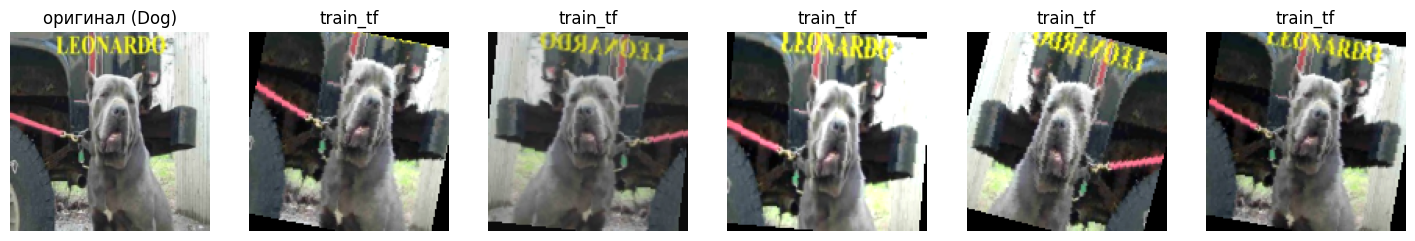

In [6]:
def denorm(x):
    """Нормализованный тензор -> картинка (H, W, 3) для plt.imshow."""
    return (x * STD + MEAN).clamp(0, 1).permute(1, 2, 0)


# Одна и та же картинка: оригинал и пять случайных аугментаций train_tf.
original = train_set.images[0]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(original.permute(1, 2, 0))
axes[0].set_title(f"оригинал ({classes[train_set.labels[0]]})")
for ax in axes[1:]:
    ax.imshow(denorm(train_tf(original)))
    ax.set_title("train_tf")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. Общие функции обучения и оценки

`fit` обучает любую модель одинаково:
- **ReduceLROnPlateau** уменьшает learning rate в 3,3 раза, если `val_loss` не улучшался 2 эпохи подряд;
- **early stopping**: обучение останавливается, если `val_loss` не улучшался `patience` эпох;
- **лучший checkpoint** (по минимальному `val_loss`) сохраняется на диск и загружается обратно после обучения;
- слои BatchNorm, у которых все параметры заморожены, переводятся в режим `eval`, иначе замороженный backbone продолжал бы менять свои статистики на новых данных.

`evaluate_on_test` считает метрики на **одном и том же** `test_set` и добавляет строку в таблицу экспериментов. Test в обучении и выборе checkpoint не участвует.

In [7]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    logits, labels = [], []
    for X, y in loader:
        with torch.autocast(DEVICE.type, enabled=USE_AMP):
            logits.append(model(X.to(DEVICE, non_blocking=True)).float().cpu())
        labels.append(y)
    return torch.cat(logits), torch.cat(labels)


def fit(model, optimizer, epochs, ckpt, patience=3):
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.3, patience=1)
    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "lr"]}
    best_loss, best_epoch = float("inf"), 0
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
                m.eval()
        loss_sum = torch.zeros((), device=DEVICE)
        correct = torch.zeros((), device=DEVICE)
        for X, y in train_loader:
            X, y = X.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.autocast(DEVICE.type, enabled=USE_AMP):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.detach() * len(y)
            correct += (logits.argmax(1) == y).sum()

        val_logits, val_labels = predict(model, val_loader)
        val_loss = criterion(val_logits, val_labels).item()
        history["train_loss"].append(loss_sum.item() / len(train_set))
        history["train_acc"].append(correct.item() / len(train_set))
        history["val_loss"].append(val_loss)
        history["val_acc"].append((val_logits.argmax(1) == val_labels).float().mean().item())
        history["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            torch.save(model.state_dict(), ckpt)
        print(f"Epoch {epoch:02d}/{epochs} | lr={history['lr'][-1]:.1e} | "
              f"train loss={history['train_loss'][-1]:.4f} acc={history['train_acc'][-1]:.4f} | "
              f"val loss={val_loss:.4f} acc={history['val_acc'][-1]:.4f}"
              f"{' *' if epoch == best_epoch else ''}")
        if epoch - best_epoch >= patience:
            print(f"Early stopping: лучшая эпоха {best_epoch}")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return history, time.perf_counter() - start, best_epoch


results, histories, test_preds, trained = [], {}, {}, {}


def evaluate_on_test(name, model, history, train_time, best_epoch):
    logits, y_true = predict(model, test_loader)
    probs = logits.softmax(1)
    y_pred = probs.argmax(1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    i = best_epoch - 1
    trained[name], histories[name] = model, history
    test_preds[name] = (y_true.numpy(), y_pred.numpy(), probs.numpy())
    results.append({
        "model": name,
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_precision": precision,
        "test_recall": recall,
        "test_f1": f1,
        "best_val_acc": history["val_acc"][i],
        "best_epoch": best_epoch,
        "epochs_run": len(history["val_acc"]),
        "train_minus_val_acc": history["train_acc"][i] - history["val_acc"][i],
        "train_time_sec": train_time,
        "trainable_params": count_trainable(model),
    })
    print(pd.DataFrame(results).tail(1).T.to_string(header=False))

## 4. Собственная CNN

Четыре блока `Conv -> ReLU -> MaxPool`, затем классификатор. Каждый `MaxPool2d(2)` уменьшает высоту и ширину вдвое: 128 -> 64 -> 32 -> 16 -> 8.

In [8]:
def conv_block(c_in, c_out):
    return nn.Sequential(nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))


def make_cnn():
    return nn.Sequential(
        conv_block(3, 32),
        conv_block(32, 64),
        conv_block(64, 128),
        conv_block(128, 128),
        nn.Flatten(),
        nn.Linear(128 * 8 * 8, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 2),
    )


# Как меняется shape после каждого блока.
x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
print(f"{'вход':<22}{tuple(x.shape)}")
for i, layer in enumerate(make_cnn()):
    x = layer(x)
    print(f"{i}: {layer.__class__.__name__:<18}{tuple(x.shape)}")

вход                  (1, 3, 128, 128)
0: Sequential        (1, 32, 64, 64)
1: Sequential        (1, 64, 32, 32)
2: Sequential        (1, 128, 16, 16)
3: Sequential        (1, 128, 8, 8)
4: Flatten           (1, 8192)
5: Linear            (1, 128)
6: ReLU              (1, 128)
7: Dropout           (1, 128)
8: Linear            (1, 2)


In [9]:
set_seed(SEED)
cnn = make_cnn().to(DEVICE)
history, train_time, best_epoch = fit(cnn, torch.optim.Adam(cnn.parameters(), lr=1e-3), epochs=15,
                                      ckpt=OUTPUT_DIR / "cnn.pt")
evaluate_on_test("CNN (baseline)", cnn, history, train_time, best_epoch)

Epoch 01/15 | lr=1.0e-03 | train loss=0.6749 acc=0.5618 | val loss=0.6188 acc=0.6761 *
Epoch 02/15 | lr=1.0e-03 | train loss=0.5882 acc=0.6870 | val loss=0.5272 acc=0.7358 *
Epoch 03/15 | lr=1.0e-03 | train loss=0.5344 acc=0.7337 | val loss=0.5142 acc=0.7483 *
Epoch 04/15 | lr=1.0e-03 | train loss=0.4906 acc=0.7665 | val loss=0.4308 acc=0.7999 *
Epoch 05/15 | lr=1.0e-03 | train loss=0.4449 acc=0.7962 | val loss=0.3952 acc=0.8165 *
Epoch 06/15 | lr=1.0e-03 | train loss=0.4065 acc=0.8182 | val loss=0.3865 acc=0.8195 *
Epoch 07/15 | lr=1.0e-03 | train loss=0.3894 acc=0.8272 | val loss=0.3618 acc=0.8358 *
Epoch 08/15 | lr=1.0e-03 | train loss=0.3536 acc=0.8470 | val loss=0.3044 acc=0.8655 *
Epoch 09/15 | lr=1.0e-03 | train loss=0.3397 acc=0.8514 | val loss=0.2915 acc=0.8724 *
Epoch 10/15 | lr=1.0e-03 | train loss=0.3159 acc=0.8662 | val loss=0.2805 acc=0.8815 *
Epoch 11/15 | lr=1.0e-03 | train loss=0.3087 acc=0.8647 | val loss=0.2677 acc=0.8842 *
Epoch 12/15 | lr=1.0e-03 | train loss=0.286

## 5. Transfer Learning: ResNet18

**Режим 1: замороженный backbone.** Все веса ResNet18, предобученные на ImageNet, заморожены (`requires_grad = False`). Заменённая голова `fc` (512 -> 2) обучается с `lr=1e-3`.

**Режим 2: fine-tuning.** Берётся лучший checkpoint режима 1, размораживается `layer4` (верхний блок ResNet18) и обучается вместе с головой с `lr=1e-4`, в 10 раз меньшим, чтобы не разрушить предобученные признаки.

В таблице время режима 2 включает и время обучения головы в режиме 1: fine-tuning стартует из неё.

In [10]:
set_seed(SEED)
resnet_head = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_head.requires_grad_(False)
resnet_head.fc = nn.Linear(resnet_head.fc.in_features, 2)
resnet_head = resnet_head.to(DEVICE)

params = [p for p in resnet_head.parameters() if p.requires_grad]
history_head, time_head, best_head = fit(resnet_head, torch.optim.Adam(params, lr=1e-3), epochs=8,
                                         ckpt=OUTPUT_DIR / "resnet18_head.pt")
evaluate_on_test("ResNet18: frozen backbone", resnet_head, history_head, time_head, best_head)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 243MB/s]


Epoch 01/8 | lr=1.0e-03 | train loss=0.1982 acc=0.9110 | val loss=0.1313 acc=0.9489 *
Epoch 02/8 | lr=1.0e-03 | train loss=0.1431 acc=0.9403 | val loss=0.1247 acc=0.9503 *
Epoch 03/8 | lr=1.0e-03 | train loss=0.1423 acc=0.9406 | val loss=0.1114 acc=0.9543 *
Epoch 04/8 | lr=1.0e-03 | train loss=0.1348 acc=0.9455 | val loss=0.1143 acc=0.9527
Epoch 05/8 | lr=1.0e-03 | train loss=0.1303 acc=0.9457 | val loss=0.1089 acc=0.9551 *
Epoch 06/8 | lr=1.0e-03 | train loss=0.1299 acc=0.9457 | val loss=0.1070 acc=0.9556 *
Epoch 07/8 | lr=1.0e-03 | train loss=0.1347 acc=0.9453 | val loss=0.1204 acc=0.9503
Epoch 08/8 | lr=1.0e-03 | train loss=0.1328 acc=0.9461 | val loss=0.1036 acc=0.9599 *
model                ResNet18: frozen backbone
test_accuracy                         0.953463
test_precision                        0.953556
test_recall                           0.953458
test_f1                               0.953461
best_val_acc                          0.959882
best_epoch                        

In [11]:
resnet_ft = copy.deepcopy(resnet_head)
resnet_ft.layer4.requires_grad_(True)

params = [p for p in resnet_ft.parameters() if p.requires_grad]
history_ft, time_ft, best_ft = fit(resnet_ft, torch.optim.Adam(params, lr=1e-4), epochs=8,
                                   ckpt=OUTPUT_DIR / "resnet18_finetune.pt")
evaluate_on_test("ResNet18: fine-tuning layer4", resnet_ft, history_ft, time_head + time_ft, best_ft)

Epoch 01/8 | lr=1.0e-04 | train loss=0.1500 acc=0.9386 | val loss=0.1064 acc=0.9572 *
Epoch 02/8 | lr=1.0e-04 | train loss=0.1020 acc=0.9596 | val loss=0.0951 acc=0.9652 *
Epoch 03/8 | lr=1.0e-04 | train loss=0.0894 acc=0.9638 | val loss=0.0885 acc=0.9647 *
Epoch 04/8 | lr=1.0e-04 | train loss=0.0723 acc=0.9729 | val loss=0.0944 acc=0.9650
Epoch 05/8 | lr=1.0e-04 | train loss=0.0657 acc=0.9754 | val loss=0.0968 acc=0.9647
Epoch 06/8 | lr=3.0e-05 | train loss=0.0471 acc=0.9834 | val loss=0.0800 acc=0.9706 *
Epoch 07/8 | lr=3.0e-05 | train loss=0.0368 acc=0.9856 | val loss=0.0861 acc=0.9692
Epoch 08/8 | lr=3.0e-05 | train loss=0.0381 acc=0.9863 | val loss=0.0852 acc=0.9708
model                ResNet18: fine-tuning layer4
test_accuracy                            0.969243
test_precision                           0.969378
test_recall                              0.969236
test_f1                                  0.969241
best_val_acc                              0.97058
best_epoch          

## 6. Таблица экспериментов

Все три модели оценены на одном `test_set`. Столбцы:
- `test_precision`, `test_recall`, `test_f1` — усреднены по двум классам поровну (macro);
- `best_val_acc`, `best_epoch` — качество и номер эпохи у сохранённого checkpoint;
- `train_minus_val_acc` — разница accuracy на train и на validation на лучшей эпохе. Accuracy на train считается по ходу эпохи с аугментациями и Dropout, поэтому она занижена, и реальное переобучение больше этой разницы;
- `train_time_sec` — время обучения; у fine-tuning включено время обучения головы.

In [12]:
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)
display(results_df.style.format({
    "test_accuracy": "{:.4f}", "test_precision": "{:.4f}", "test_recall": "{:.4f}", "test_f1": "{:.4f}",
    "best_val_acc": "{:.4f}", "train_minus_val_acc": "{:+.4f}", "train_time_sec": "{:.0f}",
    "trainable_params": "{:,}",
}))

,model,test_accuracy,test_precision,test_recall,test_f1,best_val_acc,best_epoch,epochs_run,train_minus_val_acc,train_time_sec,trainable_params
0,CNN (baseline),0.9104,0.9120,0.9104,0.9103,0.9008,15,15,+0.0016,304,"1,289,794"
1,ResNet18: frozen backbone,0.9535,0.9536,0.9535,0.9535,0.9599,8,8,-0.0138,160,"1,026"
2,ResNet18: fine-tuning layer4,0.9692,0.9694,0.9692,0.9692,0.9706,6,8,+0.0128,322,"8,394,754"


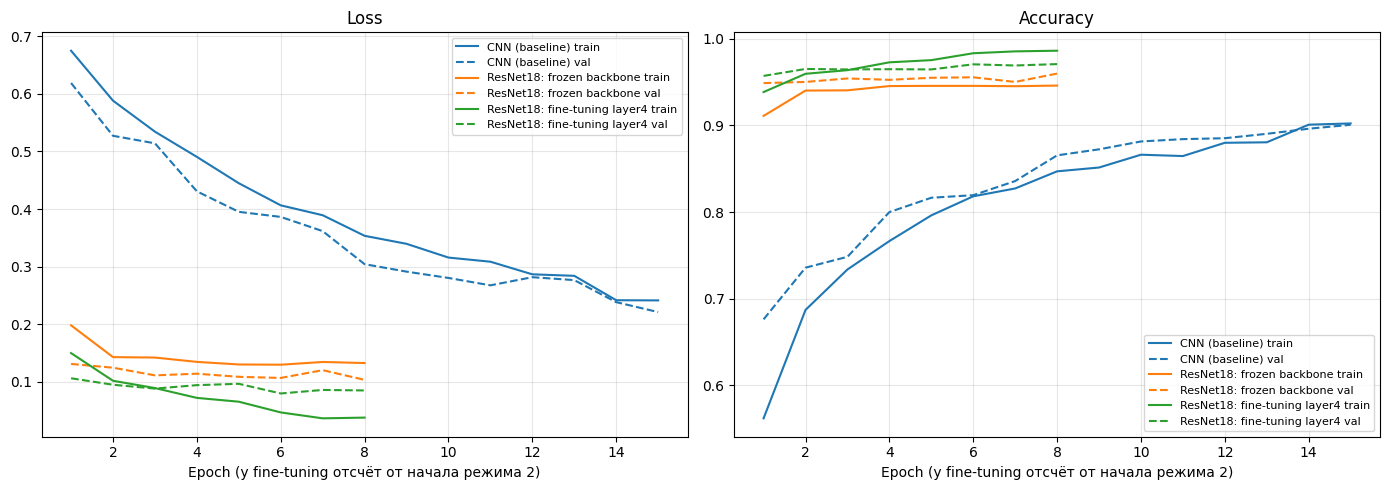

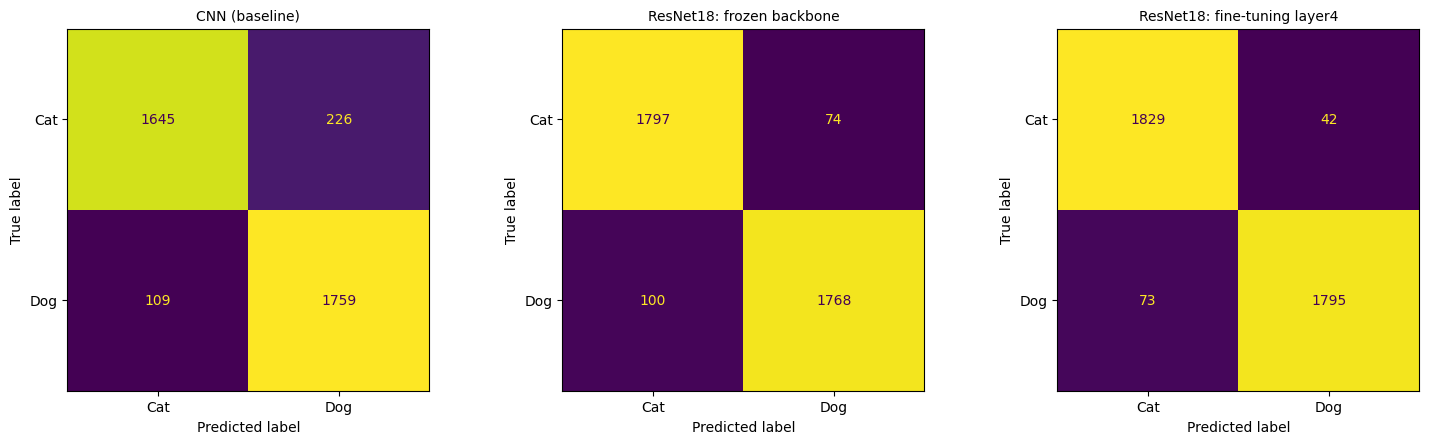

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    epochs = range(1, len(h["train_loss"]) + 1)
    line, = axes[0].plot(epochs, h["train_loss"], label=f"{name} train")
    axes[0].plot(epochs, h["val_loss"], "--", color=line.get_color(), label=f"{name} val")
    line, = axes[1].plot(epochs, h["train_acc"], label=f"{name} train")
    axes[1].plot(epochs, h["val_acc"], "--", color=line.get_color(), label=f"{name} val")
axes[0].set_title("Loss")
axes[1].set_title("Accuracy")
for ax in axes:
    ax.set_xlabel("Epoch (у fine-tuning отсчёт от начала режима 2)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curves.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, test_preds):
    y_true, y_pred, _ = test_preds[name]
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes, ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

## 7. Разбор ошибок лучшей ResNet-модели

Для Grad-CAM нужна сеть с картой признаков последнего свёрточного слоя, поэтому дальше разбирается та из двух ResNet-моделей, у которой выше `best_val_acc` (выбор по validation, не по test).

In [14]:
resnet_rows = results_df[results_df["model"].str.startswith("ResNet18")]
best_name = resnet_rows.sort_values("best_val_acc", ascending=False).iloc[0]["model"]
best_model = trained[best_name].eval()
y_true, y_pred, probs = test_preds[best_name]
print("Модель для разбора:", best_name)
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

wrong = np.where(y_true != y_pred)[0]
wrong = wrong[np.argsort(-probs[wrong].max(1))]
right = np.where(y_true == y_pred)[0]
print(f"Ошибок: {len(wrong)} из {len(y_true)}")

errors_df = pd.DataFrame({
    "file": [Path(test_paths[j]).name for j in wrong],
    "true": [classes[y_true[j]] for j in wrong],
    "pred": [classes[y_pred[j]] for j in wrong],
    **{f"P({c})": probs[wrong, k].round(3) for k, c in enumerate(classes)},
})
errors_df.to_csv(OUTPUT_DIR / "errors.csv", index=False)
display(errors_df.head(12))

Модель для разбора: ResNet18: fine-tuning layer4
              precision    recall  f1-score   support

         Cat     0.9616    0.9776    0.9695      1871
         Dog     0.9771    0.9609    0.9690      1868

    accuracy                         0.9692      3739
   macro avg     0.9694    0.9692    0.9692      3739
weighted avg     0.9694    0.9692    0.9692      3739

Ошибок: 115 из 3739


,file,true,pred,P(Cat),P(Dog)
0,1361.jpg,Cat,Dog,0.000,1.000
1,4190.jpg,Cat,Dog,0.002,0.998
2,1622.jpg,Dog,Cat,0.997,0.003
3,726.jpg,Dog,Cat,0.996,0.004
4,8678.jpg,Dog,Cat,0.995,0.005
5,3531.jpg,Cat,Dog,0.006,0.994
6,9427.jpg,Cat,Dog,0.006,0.994
7,1520.jpg,Dog,Cat,0.993,0.007
8,7038.jpg,Dog,Cat,0.988,0.012
9,10928.jpg,Dog,Cat,0.984,0.016


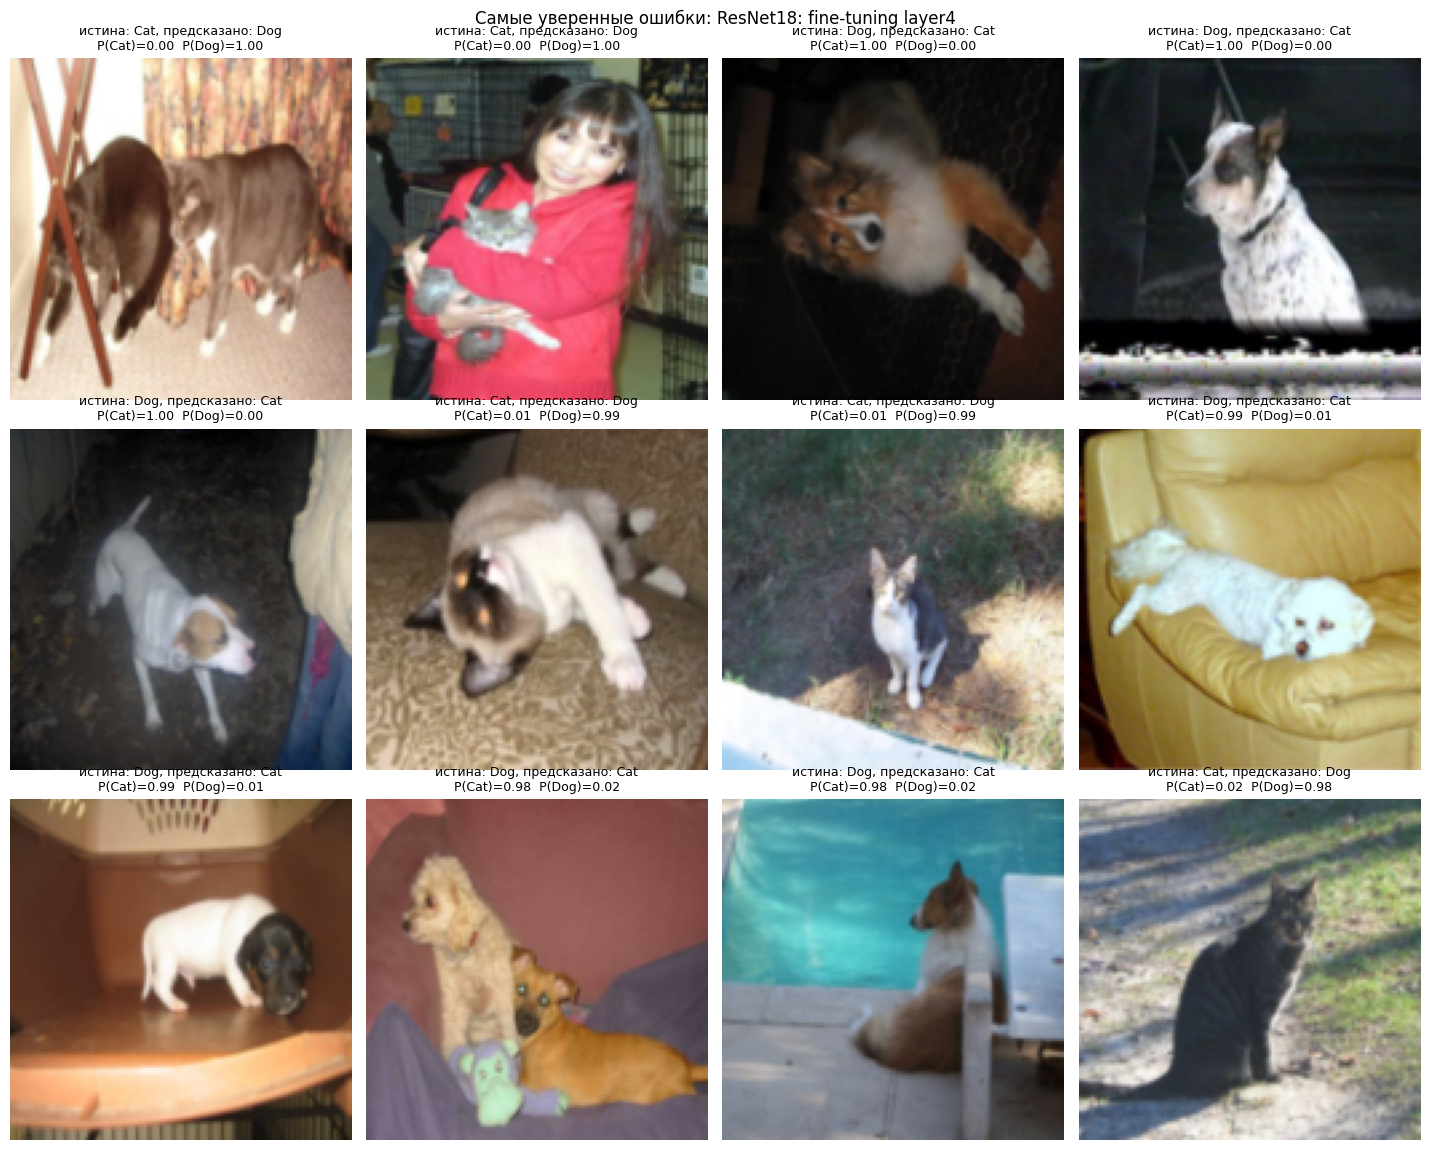

In [15]:
def show_errors(positions, title, n_cols=4):
    n_rows = int(np.ceil(len(positions) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 3.9 * n_rows))
    for ax in axes.flat:
        ax.axis("off")
    for ax, j in zip(axes.flat, positions):
        ax.imshow(denorm(test_set[j][0]))
        ax.set_title(f"истина: {classes[y_true[j]]}, предсказано: {classes[y_pred[j]]}\n"
                     + "  ".join(f"P({c})={probs[j, k]:.2f}" for k, c in enumerate(classes)), fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "errors.png", dpi=150)
    plt.show()


show_errors(wrong[:12], f"Самые уверенные ошибки: {best_name}")

## 8. Grad-CAM

**Как это работает.** Для предсказанного класса берётся градиент его логита (выхода сети до softmax) по каждому каналу карты признаков последнего свёрточного блока `layer4[-1]`. Среднее значение градиента по каналу — вес канала: чем выше вес, тем сильнее канал увеличивает уверенность в этом классе. Взвешенная сумма каналов, обрезанная снизу нулём и растянутая до размера картинки, и есть тепловая карта: красные области сильнее всего повлияли на ответ.

Карта `layer4` у картинки 128x128 имеет размер 4x4 и растягивается до размера картинки, поэтому она грубая: по ней видно область, а не контур.

Реализация — библиотека `pytorch-grad-cam`. Карты считаются сразу для всего test, чтобы можно было сравнивать их количественно.

Карты Grad-CAM: (3739, 128, 128)


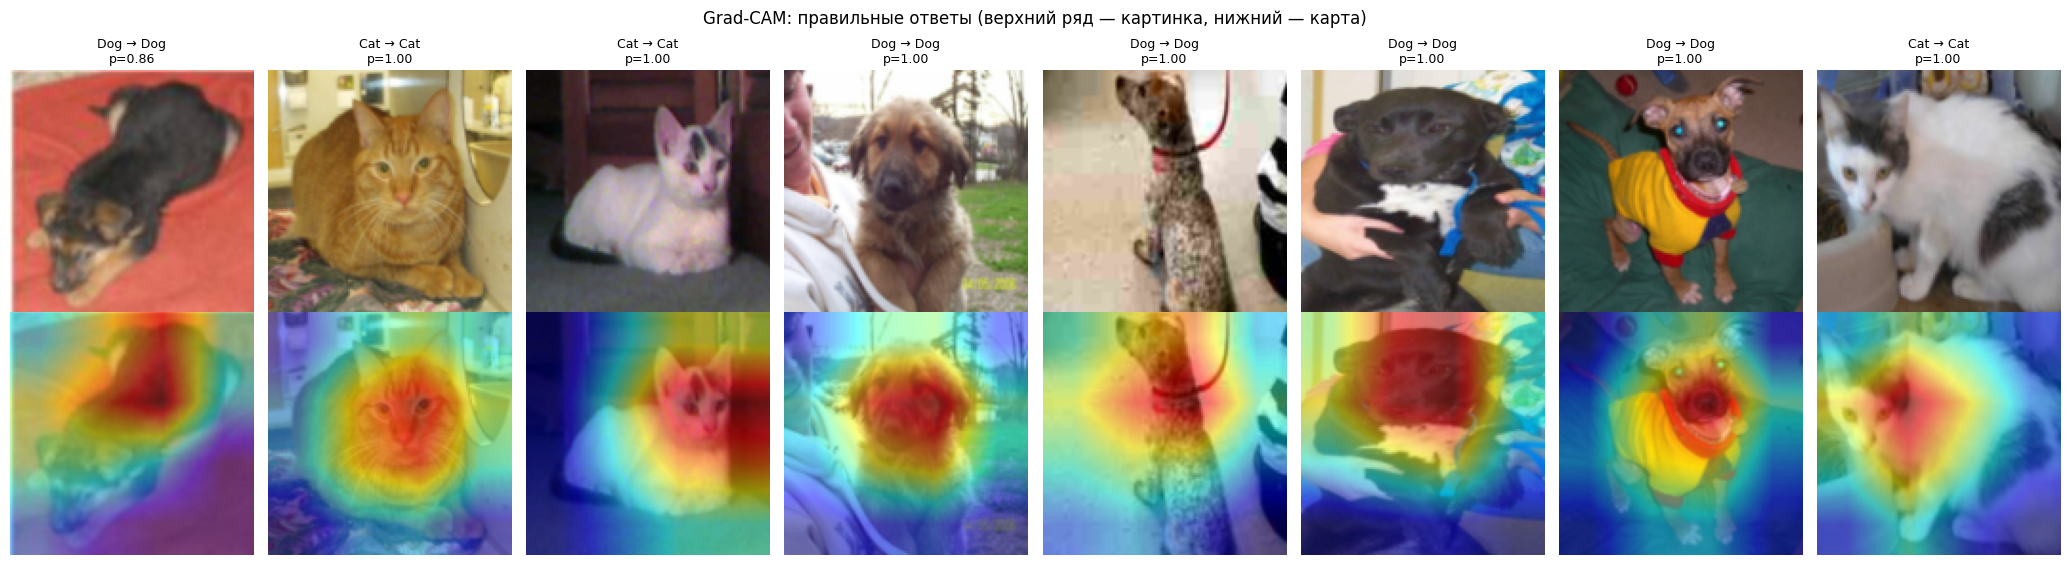

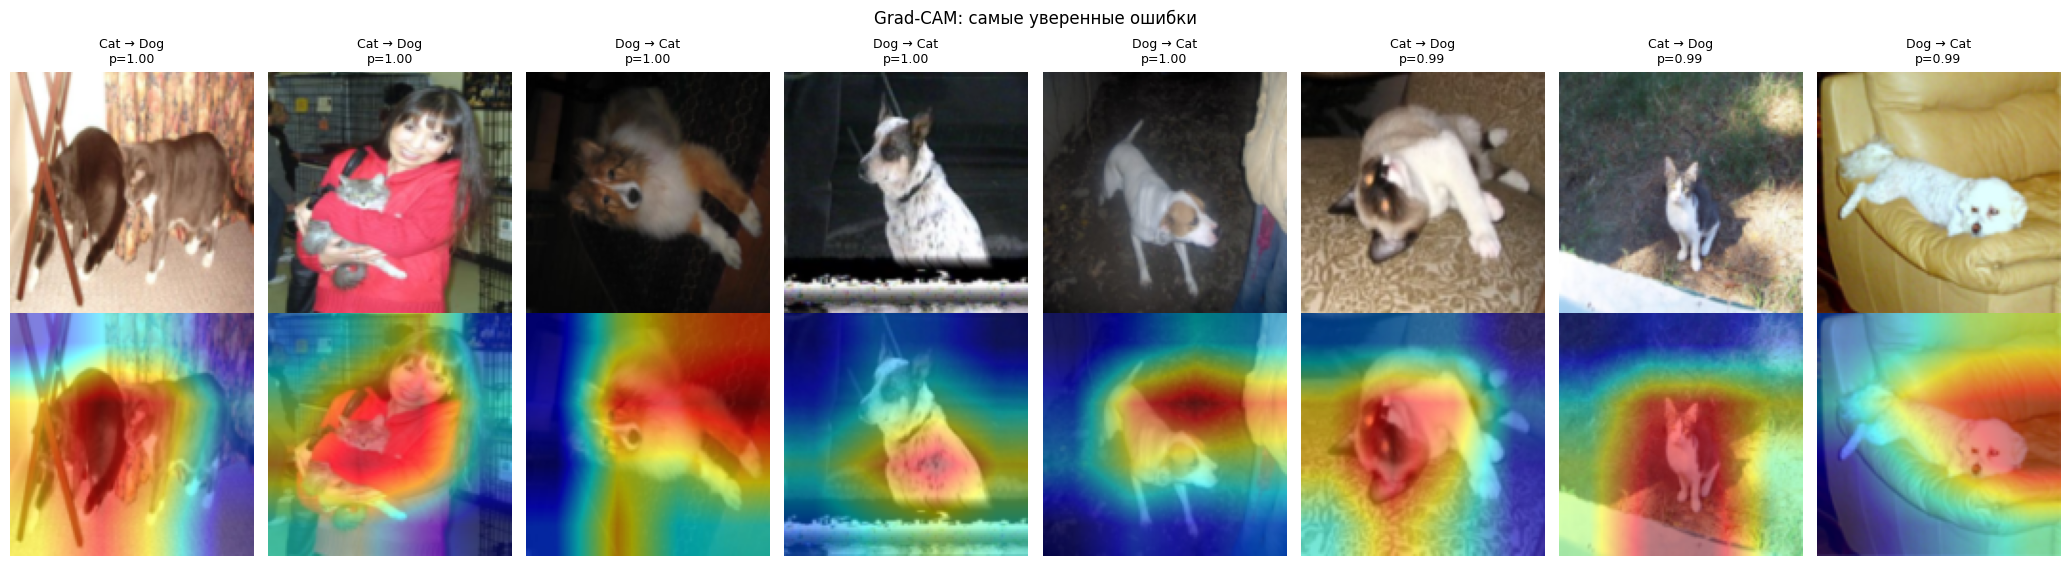

In [17]:
cam_model = copy.deepcopy(best_model).requires_grad_(True).eval()
cam = GradCAM(model=cam_model, target_layers=[cam_model.layer4[-1]])

cams = np.concatenate([cam(input_tensor=X.to(DEVICE), targets=None) for X, _ in test_loader])
print("Карты Grad-CAM:", cams.shape)


def cam_gallery(positions, title):
    fig, axes = plt.subplots(2, len(positions), figsize=(2.6 * len(positions), 5.8))
    for k, j in enumerate(positions):
        rgb = denorm(test_set[j][0]).contiguous().numpy()
        axes[0, k].imshow(rgb)
        axes[1, k].imshow(show_cam_on_image(rgb, cams[j], use_rgb=True))
        axes[0, k].set_title(f"{classes[y_true[j]]} → {classes[y_pred[j]]}\np={probs[j, y_pred[j]]:.2f}", fontsize=9)
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(SEED)
cam_gallery(rng.choice(right, 8, replace=False), "Grad-CAM: правильные ответы (верхний ряд — картинка, нижний — карта)")
cam_gallery(wrong[:8], "Grad-CAM: самые уверенные ошибки")

### Где сеть смотрит на фон

Масок «животное / фон» в датасете нет, поэтому используется приближённая оценка: доля суммарной «яркости» тепловой карты вне центрального квадрата (половина стороны картинки по центру). Эта доля — только признак для поиска кандидатов: животное не всегда в центре, поэтому каждую найденную картинку нужно посмотреть глазами.

          count      mean       50%
correct                            
False     115.0  0.721145  0.699880
True     3624.0  0.622999  0.618321


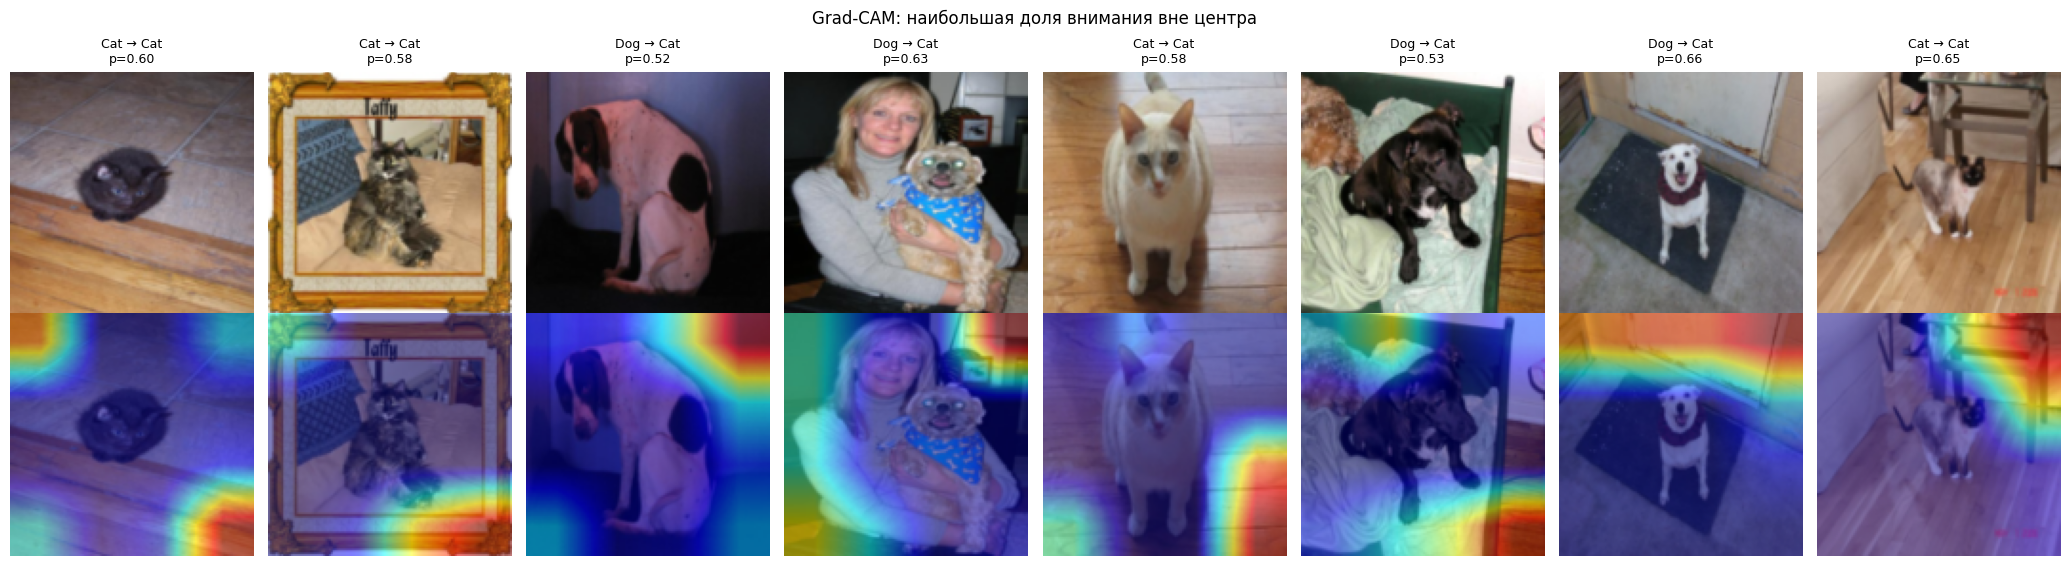

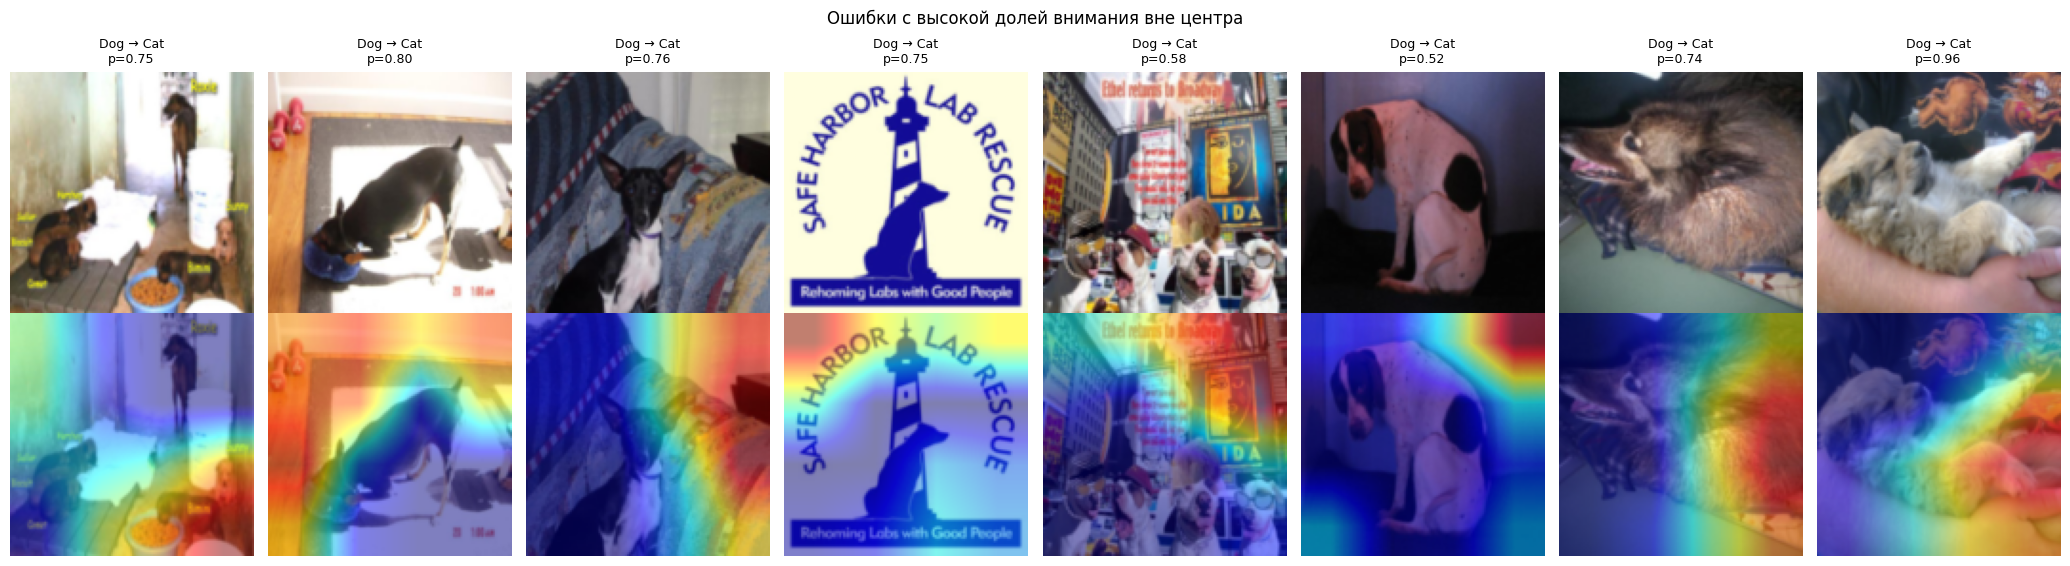

In [18]:
c = IMG_SIZE
center = np.zeros((c, c), bool)
center[c // 4:3 * c // 4, c // 4:3 * c // 4] = True
outside = np.array([m[~center].sum() / m.sum() for m in cams])

summary = pd.DataFrame({"outside_share": outside, "correct": y_true == y_pred})
print(summary.groupby("correct")["outside_share"].describe()[["count", "mean", "50%"]])

cam_gallery(np.argsort(-outside)[:8], "Grad-CAM: наибольшая доля внимания вне центра")
cam_gallery(np.intersect1d(np.argsort(-outside)[:200], wrong)[:8], "Ошибки с высокой долей внимания вне центра")

## 9. Inference для одного изображения

`classify_image` принимает путь к файлу или `PIL.Image`, проходит ту же предобработку, что и test (сначала `Resize` до `CACHE_SIZE`, затем `eval_tf`), и возвращает вероятности классов. Параметр `with_cam=True` дополнительно рисует Grad-CAM для предсказанного класса.

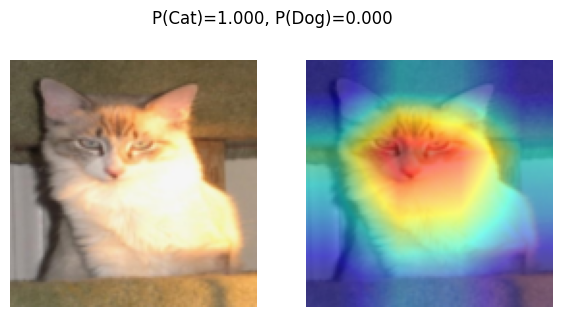

{'Cat': 0.9999997615814209, 'Dog': 2.0496490549248847e-07}

In [23]:
def classify_image(source, model=best_model, with_cam=True):
    img = source if isinstance(source, Image.Image) else Image.open(source)
    x = eval_tf(to_cache(img.convert("RGB"))).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        p = model(x).softmax(1)[0].cpu().numpy()
    result = {c: float(p[k]) for k, c in enumerate(classes)}

    if with_cam:
        rgb = denorm(x[0].cpu()).contiguous().numpy()
        fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
        axes[0].imshow(rgb)
        axes[1].imshow(show_cam_on_image(rgb, cam(input_tensor=x, targets=None)[0], use_rgb=True))
        for ax in axes:
            ax.axis("off")
        fig.suptitle(", ".join(f"P({c})={v:.3f}" for c, v in result.items()))
        plt.show()
    return result


classify_image(test_paths[0])

## 10. Выводы отдельно про GradCAM (сравнение двух сетей уже было)

- На правильных ответах модель смотрит в основном куда-то в центр животного, не обязательно на морду. Но не всегда. Иногда смотрит на фон (особенно если животное на картинке расположено в странной позе или картинка просто странная).
- На ошибках модель смотрит точно так же.
- Картинки с высокой долей внимания вне центра - действительно хороший способ находить внимание на фон.

Сеть часто путается из-за освещения или позы. Возможно, стоило бы усилить `ColorJitter` и добавить `RandomPerspective`.